In [1]:
import os, sys
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
!pip install transformers==4.57.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 176.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


### Imports

In [4]:
import gc
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import re
import tensorflow as tf
%matplotlib inline

from collections import OrderedDict
from sklearn.metrics import roc_auc_score
from tf_keras import backend as K
from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
from tf_keras.initializers import TruncatedNormal
from tf_keras.layers import Activation, Bidirectional, Dense, Dropout, Embedding, GRU, Input, TimeDistributed
from tf_keras.losses import BinaryCrossentropy
from tf_keras.metrics import AUC
from tf_keras.models import Model
from tf_keras.optimizers import Adam
from tf_keras.preprocessing.sequence import pad_sequences
from tf_keras.utils import Sequence
from tensorflow.random import set_seed
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoConfig, TFAutoModel

### Task

Given a Wikipedia Talk pages comment predict a probability for each of the following toxicity types:

> 1. toxic
> 2. severe_toxic
> 3. obscene
> 4. threat
> 5. insult
> 6. identity_hate

###Data Preprocessing

In [5]:
def preprocess_kaggle_dataset(data_path, preprocessed_data_path, labels_path=None):
    """
       Function to preprocess and store a kaggle dataset. The dataset is stored as csv and loaded as pandas data frame.
       Columns legend: The legend of the columns in the data frame:
           [u'id', u'comment_text', u'toxic', u'severe_toxic', u'obscene', u'threat', u'insult', u'identity_hate']
       Labels indices: The inidices of the categories after preprocessing:
           toxic: 0
           severe_toxic: 1
           obscene: 2
           threat: 3
           insult: 4
           identity_hate: 5
       :param data_path: The path of the raw kaggle data.
       :param preprocessed_data_path: The path where the preprocessed kaggle data will be stored.
       :param labels_path: The path containing the labels. Used only for test set where the labels were given in a
                           separate file
       :param retain_dot: If True the dot symbol is retained, otherwise it is substituted by a space.
       :return: The preprocessed dataset.
       """
    kaggle_data = pd.read_csv(data_path)
    if labels_path != None:
        kaggle_labels = pd.read_csv(labels_path)
        kaggle_data = pd.merge(kaggle_data, kaggle_labels, on='id')
        kaggle_data = kaggle_data[kaggle_data['toxic'] > -1]
    ids = kaggle_data['id'].tolist()
    comments = [clean(str(comment)) for comment in tqdm(kaggle_data['comment_text'].tolist())]
    preprocessed_dataset = {
        'ids': ids,
        'comments': comments,
        'labels': kaggle_data[kaggle_data.keys()[-6:]].values.tolist()
    }
    with open(file=preprocessed_data_path, mode="w") as fout:
        json.dump(obj=preprocessed_dataset, fp=fout)


def clean(text, to_lower = True):

    """
    No special tokens - use fasttext embeddings instead ( http , domain , IP ).
    Alternatively can use special tokens like ■http■ , ■domain■ , ■IP■

    There are two regex for two different datetime types and two regex for two different date types

    Keep multiple full stops together as there are fasttext embeddings for them ( .. ... .... ..... )
    """

    contractions = {
        "ain't": "not",
        "can't": "cannot",
        "e'er": "ever",
        "i'd": "I 'd",
        "i'll": "I 'll",
        "i'm": "I am",
        "i've": "I have",
        "let's": "let us",
        "ma'am": "madam",
        "ne'er": "never",
        "o'clock": "of the clock",
        "o'er": "over",
        "shan't": "shall not",
        "won't": "will not",
        "'tis": "it is",
        "'twas": "it was",
        "y'all": " you all",
        "y'alls": "you all",
        "y'all's": "you all",
        "y'know": "you know",
        "gov't": "govt",
        "g'day": "good day",
        "mf'n": "mother fuckin",
        "f'n": "fucking",
        "qur'an": "quran",
        "qu'ran": "quran",
        "g'damnit": "god damnit",
        "c'mon": "come on",
        "agains't": "against",
        "f'ing": "fucking",
        "f'uck": "fuck",
        "fuck'in": "fuckin",
        "f'in": "fuckin",
        "fuck'n": "fuckin",
        "f'kn": "fuckin",
        "mo'fucka": "motherfucker"

    }

    # add whitespace at start and end of text
    text = " " + text + " "

    # remove http links or replace them with http
    HTTP = re.compile(r"""          # Capture 1: entire matched URL
          (?:
          [Hh][Tt][Tt][Pp][Ss]?:                # URL protocol and colon
            (?:
              /{1,3}                # 1-3 slashes
              |                 #   or
              [a-z0-9%]             # Single letter or digit or '%'
                                               # (Trying not to match e.g. "URI::Escape")
            )
            | (?:www\.) | (?:www2\.) | (?:www3\.)
            |                   #   or
                                               # looks like domain name followed by a slash:
            [A-Za-z0-9.\-]+[.]
            (?:[a-z]{2,13})
            /
          )
          (?:                   # One or more:
            [^\s()<>{}\[\]]+            # Run of non-space, non-()<>{}[]
            |                   #   or
            \([^\s()]*?\([^\s()]+\)[^\s()]*?\) # balanced parens, one level deep: (...(...)...)
            |
            \([^\s]+?\)             # balanced parens, non-recursive: (...)
          )+
          (?:                   # End with:
            \([^\s()]*?\([^\s()]+\)[^\s()]*?\) # balanced parens, one level deep: (...(...)...)
            |
            \([^\s]+?\)             # balanced parens, non-recursive: (...)
            |                   #   or
            [^\s`!()\[\]{};:'".,<>?«»“”‘’]  # not a space or one of these punct chars
          )
          """, flags=re.VERBOSE)
    text = re.sub(HTTP, " http ", text)

    # remove IPs or replace them with IP
    IP = re.compile(r"""(?<!\d)[\d*x]{1,3}\.[\d*x]{1,3}\.[\d*x]{1,3}\.[\d*x]{1,3}(?!\d)""", flags=re.IGNORECASE)
    text = re.sub(IP, " IP ", text)

    # remove emails or replace with email
    EMAIL = re.compile(
        r"""(?:[a-z0-9!#$%&*+\/=?^_`{|}~-]+(?:\.[a-z0-9!#$%&'*+\/=?^_`{|}~-]+)*(?:@)(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(?:\.))+[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)|(?:[a-z0-9!#$%&*+\/=?^_`{|}~-]+(?:\.[a-z0-9!#$%&'*+\/=?^_`{|}~-]+)*(?:\sat\s)(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(?:\sdot\s))+[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)""",
        flags=re.IGNORECASE)
    text = re.sub(EMAIL, " email ", text)

    # remove domains or replace them with domain
    URLS = re.compile(
        r"""(?i)\b((?:https?:(?:/{1,3}|[a-z0-9%])|[a-z0-9.\-]+[.](?:com|net|org|edu|gov|mil|aero|asia|biz|cat|coop|info|int|jobs|mobi|museum|name|post|pro|tel|travel|xxx|ac|ae|af|ag|ai|am|ao|aq|ar|au|aw|ax|az|ba|bb|bd|bf|bg|bh|bj|bm|bn|bo|br|bs|bt|bv|bw|bz|ca|cc|cd|cf|cg|ch|ci|ck|cl|cm|cn|co|cr|cs|cu|cv|cx|cy|cz|dd|de|dj|dk|dm|dz|ec|ee|eh|es|eu|fi|fj|fk|fm|fo|fr|ga|gb|gd|ge|gf|gg|gh|gi|gl|gm|gn|gp|gq|gr|gs|gt|gu|gw|gy|hk|hm|hn|hr|ht|hu|ie|il|io|iq|ir|je|jm|jo|jp|ke|kg|kh|ki|km|kn|kp|kr|kw|ky|kz|la|lb|lc|li|lk|lr|ls|lt|lu|lv|ly|ma|mc|mg|mh|mk|ml|mm|mn|mp|mq|mt|mu|mv|mw|mx|mz|na|nc|ne|nf|ng|ni|nl|np|nr|nu|nz|om|pa|pe|pf|pg|ph|pk|pl|pm|pn|pr|pt|pw|py|qa|re|ro|rs|ru|rw|sa|sb|sd|se|sg|sh|si|sj|Ja|sk|sl|sm|sn|sr|ss|st|su|sv|sx|sy|sz|td|tf|tg|th|tj|tk|tl|tn|tp|tr|tt|tv|tw|tz|ua|ug|uk|uy|uz|va|vc|ve|vg|vi|vn|vu|wf|ws|ye|yt|yu|za|zm|zw)/)(?:[^\s()<>{}\[\]]+|\([^\s()]*?\([^\s()]+\)[^\s()]*?\)|\([^\s]+?\))+(?:\([^\s()]*?\([^\s()]+\)[^\s()]*?\)|\([^\s]+?\)|[^\s`!()\[\]{};:'".,<>?«»“”‘’])|(?:(?<!@)[a-z0-9]+(?:[.\-][a-z0-9]+)*[.](?:com|net|org|edu|gov|mil|aero|asia|biz|cat|coop|info|int|jobs|mobi|museum|name|post|pro|tel|travel|xxx|ac|ae|af|ag|ai|am|ao|aq|ar|au|aw|ax|az|ba|bb|bd|bf|bg|bh|bj|bm|bn|bo|br|bs|bt|bv|bw|bz|ca|cc|cd|cf|cg|ch|ci|ck|cl|cm|cn|co|cr|cs|cu|cv|cx|cy|cz|dd|de|dj|dk|dm|dz|ec|ee|eh|es|eu|fi|fj|fk|fm|fo|fr|ga|gb|gd|ge|gf|gg|gh|gi|gl|gm|gn|gp|gq|gr|gs|gt|gu|gw|gy|hk|hm|hn|hr|ht|hu|ie|il|io|iq|ir|je|jm|jo|jp|ke|kg|kh|ki|km|kn|kp|kr|kw|ky|kz|la|lb|lc|li|lk|lr|ls|lt|lu|lv|ly|ma|mc|mg|mh|mk|ml|mm|mn|mp|mq|mt|mu|mv|mw|mx|mz|na|nc|ne|nf|ng|ni|nl|np|nr|nu|nz|om|pa|pe|pf|pg|ph|pk|pl|pm|pn|pr|pt|pw|py|qa|re|ro|rs|ru|rw|sa|sb|sd|se|sg|sh|si|sj|Ja|sk|sl|sm|sn|sr|ss|st|su|sv|sx|sy|sz|td|tf|tg|th|tj|tk|tl|tn|tp|tr|tt|tv|tw|tz|ua|ug|uk|uy|uz|va|vc|ve|vg|vi|vn|vu|wf|ws|ye|yt|yu|za|zm|zw)\b/?(?!@)))""")
    text = re.sub(URLS, " domain ", text)

    # remove date:time or replace them with datetime
    DATETIME = re.compile(r"""
            ((?<!\d)(\d{4}|\d{1,2})[-.\\/](\d{4}|\d{1,2})[-.\\/](\d{4}|\d{1,2})[^\S\n]?[-,:;]?[^\S\n]*\d{2}[.:]\d{2}([.:]\d{2})?(?!\d))
            |
            ((?<!\d)\d{2}[.:]\d{2}([.:]\d{2})?[^\S\n]*[-,:;]?[^\S\n]?(?<!\d)(\d{4}|\d{1,2})[-.\\/](\d{4}|\d{1,2})[-.\\/](\d{4}|\d{1,2})(?!\d))
            """, flags=re.VERBOSE)
    text = re.sub(DATETIME, " datetime ", text)

    # remove time, date, month, year or replace them with datetime
    DATETIME2 = re.compile(r"""
        (?<!\d)\d{2}[.:]\d{2}([.:]\d{2})?\s*[,]?\s*\d{1,2}\s*[,]?\s*(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)\s*[,]?\s*(\d{4}|\d{2})(?!\d)
        |
        (?<!\d)\d{2}[.:]\d{2}([.:]\d{2})?\s*[,]?\s*(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)\s*[,]?\s*\d{1,2}\s*[,]?\s*(\d{4}|\d{2})(?!\d)
        |
        (?<!\d)\d{2}[.:]\d{2}([.:]\d{2})?\s*[,]?\s*(\d{4}|\d{2})\s*[,]?\s*(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)\s*[,]?\s*\d{1,2}(?!\d)
        |
        (?<!\d)\d{1,2}\s*[,]?\s*(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)\s*[,]?\s*(\d{4}|\d{2})\s*[,]?\s*\d{2}[.:]\d{2}([.:]\d{2})?(?!\d)
        |
        (january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)\s*[,]?\s*\d{1,2}\s*[,]?\s*(\d{4}|\d{2})\s*[,]?\s*\d{2}[.:]\d{2}([.:]\d{2})?(?!\d)
        |
        (?<!\d)(\d{4}|\d{2})\s*[,]?\s*(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)\s*[,]?\s*\d{1,2}\s*[,]?\s*\d{2}[.:]\d{2}([.:]\d{2})?(?!\d)
        """, flags=re.VERBOSE | re.IGNORECASE)
    text = re.sub(DATETIME2, " datetime ", text)

    # remove date or replace them with date
    DATE = re.compile(r"""(?<!\d)(\d{4}|\d{1,2})[-.\\/]\d{2}[-.\\/](\d{4}|\d{1,2})(?!\d)""")
    text = re.sub(DATE, " date ", text)

    # remove date, month, year or replace them with date
    DATE2 = re.compile(r"""
        ((?<!\d)\d{1,2}[^\S\n]?[\,]?[^\S\n]?(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)[^\S\n]?[\,]?[^\S\n]?(\d{4}|\d{2})(?!\d))
        |
        ((january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)[^\S\n]?[\,]?[^\S\n]?\d{1,2}[^\S\n]?[\,]?[^\S\n]?(\d{4}|\d{2})(?!\d))
        |
        ((?<!\d)(\d{4}|\d{2})[^\S\n]?[\,]?[^\S\n]?(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec)[^\S\n]?[\,]?[^\S\n]?\d{1,2}(?!\d))
        |
        ((?<!\d)(\d{4}|\d{2})[^\S\n]?[\,]?[^\S\n]?(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec))
        |
        ((?<!\d)\d{1,2}[^\S\n]?[\,]?[^\S\n]?(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|october|oct|november|nov|december|dec))
        """, flags=re.VERBOSE | re.IGNORECASE)
    text = re.sub(DATE2, " date ", text)

    # remove telephones or replace them with telephone
    TEL = re.compile(r"""(\((?<![\d\-])((\+[ ]?)?[0-9]{1,3}[-\.\\/ ]?)?[0-9]{3}\)|(?<![\d\-])((\+[ ]?)?[0-9]{1,3}[-\.\\/ ]?)?[0-9]{3})[-\.\\/ ][0-9]{3}[-\.\\/ ][0-9]{4}(?![\d\-])""")
    text = re.sub(TEL, " telephone ", text)

    # remove numbers or replace them with number
    NUMBER = re.compile(r"""(?<![\w])(((\d+\,)*\d+(\.\d+)?)|((\d+\,)+\d+))(?![\w])""")
    text = re.sub(NUMBER, " number ", text)

    # replace ’`´ with '
    text = re.sub("[\’\`\´]", "\'", text)

    # remove all except A-Za-z0-9().,!?\'
    text = re.sub(r"[^A-Za-z0-9().,!?\']", " ", text)

    # separate full stops, keep consecutive full stops together as there are embeddings for them
    text = re.sub(r"(\.+)", r" \1 ", text)

    # separate ,
    text = re.sub(r",", " , ", text)

    # separate !
    text = re.sub(r"!", " ! ", text)
    # text = re.sub(r"(\!+)", r" \1 ", text)

    # separate ?
    text = re.sub(r"\?", " ? ", text)

    # separate ( and )
    text = re.sub(r"\(", " ( ", text)
    text = re.sub(r"\)", " ) ", text)

    # replace ol' contraction with old
    text = re.sub(r"\sol'", " old ", text, flags=re.IGNORECASE)

    # remove ' at start and end of words but not 'd 'm 's 'll 're 've 'tis 'twas
    text = re.sub(r"(?<![A-Za-z])'(?!(d|m|s|ll|re|ve|tis|twas)\s)|'(?![A-Za-z])", " ", text, flags=re.IGNORECASE)

    if to_lower:
        # lowercase all words except special token IP
        words = [word.lower() if word not in ['IP'] else word for word in text.split()]

        # replace contractions with the right form
        words = [contractions[word] if word in contractions else word for word in words]
    else:
        # replace contractions with the right form
        words = [contractions[word.lower()] if word.lower() in contractions else word for word in text.split()]

    # join words and add whitespace at start and end of text
    text = " ".join(words)
    text = " " + text + " "

    # replace contractions with the right form
    text = re.sub(r"\s(i\s+)?'m\s", " I am ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'s\s", " \'s ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'ve\s", " have ", text, flags=re.IGNORECASE)
    text = re.sub(r"n\'t\s", " not ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'re\s", " are ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'d\s", " \'d ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'ll\s", " \'ll ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'ed\s", " \'ed ", text, flags=re.IGNORECASE)

    # replace wrong spelling contractions with the right form (e.g. did'nt , is'nt , did't , would't , he'l , would'v , i'v , you'ld)
    text = re.sub(r"\'nt\s", " not ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'t\s", " not ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'l\s", " \'ll ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'v\s", " have ", text, flags=re.IGNORECASE)
    text = re.sub(r"\'ld\s", " 'd ", text, flags=re.IGNORECASE)

    # remove ' between words (e.g. the'fortyfive, o'donohue)
    # text = re.sub(r"([A-Za-z])(')([A-Za-z])", r"\1 \3", text, flags=re.IGNORECASE)
    text = re.sub(r"([A-Za-z]+)(')([A-Za-z]+)(')([A-Za-z]+)", r" \1 \3 \5 ", text, flags=re.IGNORECASE)
    text = re.sub(r"([A-Za-z]+)(')([A-Za-z]+)", r" \1 \3 ", text, flags=re.IGNORECASE)

    # replace multiple whitespace with a single one
    text = re.sub(r"\s+", " ", text)

    if text in {" ", ""}:
        text = "NaN"

    return text.strip().split()


# Run the preprocessing

kaggle_train_data_path = '/content/drive/My Drive/data/train.csv'
kaggle_preprocessed_train_data_path = '/content/drive/My Drive/data/train.pp.json'
kaggle_test_data_path = '/content/drive/My Drive/data/test.csv'
kaggle_preprocessed_test_data_path = '/content/drive/My Drive/data/test.pp.json'
kaggle_test_labels_path = '/content/drive/My Drive/data/test_labels.csv'

preprocess_kaggle_dataset(
    data_path=kaggle_train_data_path,
    preprocessed_data_path=kaggle_preprocessed_train_data_path
)

preprocess_kaggle_dataset(
    data_path=kaggle_test_data_path,
    preprocessed_data_path=kaggle_preprocessed_test_data_path,
    labels_path=kaggle_test_labels_path
)


<>:190: SyntaxWarning: invalid escape sequence '\`'
<>:190: SyntaxWarning: invalid escape sequence '\`'
/tmp/ipython-input-580/3411185964.py:190: SyntaxWarning: invalid escape sequence '\`'
  text = re.sub("[\’\`\´]", "\'", text)


  0%|          | 0/159571 [00:00<?, ?it/s]

  0%|          | 0/63978 [00:00<?, ?it/s]

###Embeddings Preprocessing

In [6]:
def export_dataset_vocabulary(dataset_path):
    vocabulary = set()
    with open(file=dataset_path, mode='r') as fin:
        dataset = json.load(fp=fin)
    for comment in tqdm(dataset['comments']):
        vocabulary.update(comment)
    return vocabulary


def export_embeddings(embeddings_path, datasets_paths):
    vocabulary = set()
    for dataset_path in datasets_paths:
        vocabulary = vocabulary | export_dataset_vocabulary(dataset_path)

    word2index = {}
    embeddings = []
    with open(file=embeddings_path, mode='r') as fin:
        word_index = 2
        for line in tqdm(fin, total=400000):
            values = line.split()
            word = values[0]
            if word in vocabulary:
                word2index[values[0]] = word_index
                word_index += 1
                embeddings.append(np.expand_dims(np.asarray(values[1:], dtype=np.float32), axis=0))
    embeddings.insert(0, np.mean(embeddings, axis=0))
    embeddings.insert(0, np.zeros((1, embeddings[0].shape[1]), dtype=np.float32))
    embeddings = np.concatenate(embeddings, axis=0)

    with open(file=embeddings_path.replace('.txt', '.npy'), mode='wb') as fout:
        np.save(file=fout, arr=embeddings)

    with open(file=embeddings_path.replace('.txt', '.w2i.json'), mode='w') as fout:
        json.dump(obj=word2index, fp=fout)

train_data_path = '/content/drive/My Drive/data/train.pp.json'
test_data_path = '/content/drive/My Drive/data/test.pp.json'
embeddings_path = '/content/drive/My Drive/data/glove.6B.300d.txt'

export_embeddings(embeddings_path, [train_data_path, test_data_path])


  0%|          | 0/159571 [00:00<?, ?it/s]

  0%|          | 0/63978 [00:00<?, ?it/s]

  0%|          | 0/400000 [00:00<?, ?it/s]

###Calculate statistics

In [7]:
def get_dataset_statistics(kaggle_data_path):
    with open(file=kaggle_data_path, mode='r') as fin:
        kaggle_data = json.load(fp=fin)

    kaggle_labels = np.asarray(kaggle_data['labels'])
    toxic_distribution = np.mean(kaggle_labels, axis=0)
    non_toxic_percentage = np.mean(np.sum(kaggle_labels, axis=1) == 0)
    return len(kaggle_labels), np.append(toxic_distribution, non_toxic_percentage)

def print_label_distribution(toxic_distribution):
    print('Label distribution')
    for i, label in enumerate(['Toxic', 'Severe toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate', 'Non toxic']):
        print(f'|__ {label:<13}: {100 * toxic_distribution[i]:>5.2f}%')

kaggle_preprocessed_train_data_path = '/content/drive/My Drive/data/train.pp.json'
kaggle_preprocessed_test_data_path = '/content/drive/My Drive/data/test.pp.json'

train_instances, train_distribution = get_dataset_statistics(kaggle_preprocessed_train_data_path)
test_instances, test_distribution = get_dataset_statistics(kaggle_preprocessed_test_data_path)

print(f'Train data ({train_instances} instances)')
print('---')
print_label_distribution(train_distribution)

print()
print('====================')
print()

print(f'Test data ({test_instances} instances)')
print('---')
print_label_distribution(test_distribution)

Train data (159571 instances)
---
Label distribution
|__ Toxic        :  9.58%
|__ Severe toxic :  1.00%
|__ Obscene      :  5.29%
|__ Threat       :  0.30%
|__ Insult       :  4.94%
|__ Identity Hate:  0.88%
|__ Non toxic    : 89.83%


Test data (63978 instances)
---
Label distribution
|__ Toxic        :  9.52%
|__ Severe toxic :  0.57%
|__ Obscene      :  5.77%
|__ Threat       :  0.33%
|__ Insult       :  5.36%
|__ Identity Hate:  1.11%
|__ Non toxic    : 90.24%


### Splitting the data

In [8]:
def split_data(train_data_path, train_percentage):
    with open(file=train_data_path, mode='r') as fin:
        train_data = json.load(fp=fin)

    instances = [instance for instance in zip(train_data['ids'], train_data['comments'], train_data['labels'])]
    random.seed(5392)
    random.shuffle(instances)

    instances_nb = len(instances)

    train_index = np.round(train_percentage * instances_nb).astype(int)
    train_instances = instances[:train_index]
    development_instances = instances[train_index:]

    train_data = {'ids': [], 'comments': [], 'labels': []}
    for comment_id, comment, label in tqdm(train_instances):
        train_data['ids'].append(comment_id)
        train_data['comments'].append(comment)
        train_data['labels'].append(label)

    development_data = {'ids': [], 'comments': [], 'labels': []}
    for comment_id, comment, label in tqdm(development_instances):
        development_data['ids'].append(comment_id)
        development_data['comments'].append(comment)
        development_data['labels'].append(label)

    with open(file=train_data_path.replace('.json', '.train.split.json'), mode="w") as fout:
        json.dump(obj=train_data, fp=fout)

    with open(file=train_data_path.replace('.json', '.dev.split.json'), mode="w") as fout:
        json.dump(obj=development_data, fp=fout)

train_data_path = '/content/drive/My Drive/data/train.pp.json'
split_data(train_data_path=train_data_path, train_percentage=0.9)

train_data_path = '/content/drive/My Drive/data/train.pp.train.split.json'
development_data_path = '/content/drive/My Drive/data/train.pp.dev.split.json'
test_data_path = '/content/drive/My Drive/data/test.pp.json'


train_instances, train_distribution = get_dataset_statistics(train_data_path)
development_instances, development_distribution = get_dataset_statistics(development_data_path)
test_instances, test_distribution = get_dataset_statistics(test_data_path)

print(f'Train data ({train_instances} instances)')
print('---')
print_label_distribution(train_distribution)

print()
print('====================')
print()

print(f'Development data ({development_instances} instances)')
print('---')
print_label_distribution(development_distribution)

print()
print('====================')
print()

print(f'Test data ({test_instances} instances)')
print('---')
print_label_distribution(test_distribution)

  0%|          | 0/143614 [00:00<?, ?it/s]

  0%|          | 0/15957 [00:00<?, ?it/s]

Train data (143614 instances)
---
Label distribution
|__ Toxic        :  9.63%
|__ Severe toxic :  1.01%
|__ Obscene      :  5.31%
|__ Threat       :  0.31%
|__ Insult       :  4.96%
|__ Identity Hate:  0.88%
|__ Non toxic    : 89.79%


Development data (15957 instances)
---
Label distribution
|__ Toxic        :  9.18%
|__ Severe toxic :  0.89%
|__ Obscene      :  5.14%
|__ Threat       :  0.24%
|__ Insult       :  4.69%
|__ Identity Hate:  0.91%
|__ Non toxic    : 90.24%


Test data (63978 instances)
---
Label distribution
|__ Toxic        :  9.52%
|__ Severe toxic :  0.57%
|__ Obscene      :  5.77%
|__ Threat       :  0.33%
|__ Insult       :  5.36%
|__ Identity Hate:  1.11%
|__ Non toxic    : 90.24%


###Plotting the results

In [9]:
def plot_history(hs, epochs, metric):
    print()
    plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = [15, 8]
    plt.rcParams['font.size'] = 16
    plt.clf()
    for label in hs:
        plt.plot(hs[label].history[metric], label='{0:s} train {1:s}'.format(label, metric), linewidth=2)
        plt.plot(hs[label].history['val_{0:s}'.format(metric)], label='{0:s} validation {1:s}'.format(label, metric), linewidth=2)
    x_ticks = np.arange(epochs)
    plt.xticks(ticks=x_ticks, labels=x_ticks + 1)
    plt.xlabel('Epochs')
    plt.ylabel('Loss' if metric=='loss' else 'AUC')
    plt.legend()
    plt.show()

###Data Loader

In [10]:
class ToxicityDataLoader(Sequence):
    def __init__(self, instances, batch_size, shuffle, max_length, embeddings=None, bert=None):
        [setattr(self, name, value) for name, value in locals().items() if name != 'self']
        if self.shuffle:
            random.shuffle(self.instances)
        if self.embeddings !=None:
            self.tokenizer_type = 'embeddings'
            with open(file=f'{embeddings}.w2i.json', mode='r') as fin:
                self.word2index = json.load(fp=fin)
        if self.bert != None:
            self.tokenizer_type = 'bert'
            self.tokenizer = AutoTokenizer.from_pretrained(bert)

    def __len__(self):
        return int(np.ceil(len(self.instances) / self.batch_size))

    def __getitem__(self, i):
        start_index = i * self.batch_size
        end_index = (i + 1) * self.batch_size
        instances, labels = zip(*self.instances[start_index: end_index])
        instances_indices = self.vectorize(instances)
        return instances_indices, np.asarray(labels)

    def vectorize(self, instances):
        if self.tokenizer_type == 'embeddings':
            indices = []
            for instance in instances:
                instance_indices=[]
                for word in instance:
                    if word in self.word2index:
                        instance_indices.append(self.word2index[word])
                    else:
                        instance_indices.append(1)
                indices.append(instance_indices)

            indices = pad_sequences(
                indices,
                maxlen=self.max_length,
                padding='post',
                truncating='post'
            )
        else:
            indices = np.asarray(
                self.tokenizer.batch_encode_plus(
                    [' '.join(instance) for instance in instances],
                    padding=True,
                    truncation=True,
                    max_length=self.max_length,
                    add_special_tokens=True
                )['input_ids'],
                dtype=np.int32
            )
        return indices

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.instances)

###Callbacks



In [11]:
class ReturnBestEarlyStopping(EarlyStopping):
    def __init__(self, **kwargs):
        super(ReturnBestEarlyStopping, self).__init__(**kwargs)

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            if self.verbose > 0:
                print(f'\nEpoch {self.stopped_epoch + 1}: early stopping')
        elif self.restore_best_weights:
            if self.verbose > 0:
                print('Restoring model weights from the end of the best epoch.')
            self.model.set_weights(self.best_weights)


###Toxicity Classifier

In [12]:
class ToxicityClassifier:
    def __init__(self):
        self.data_loader = ToxicityDataLoader

    def load_dataset(self, dataset_path):
        with open(file=dataset_path, mode='r') as fin:
            dataset = json.load(fp=fin)

        return [instance for instance in zip(dataset['comments'], dataset['labels'])]

    def create_generator(self, dataset_path, batch_size, shuffle, max_length, embeddings=None, bert=None):
        instances = self.load_dataset(dataset_path)
        generator = self.data_loader(
            instances=instances,
            batch_size=batch_size,
            shuffle=shuffle,
            max_length=max_length,
            embeddings=embeddings,
            bert=bert
        )
        return generator

    def build_model(self, train_parameters=None):
        raise NotImplementedError

    def train(self, configuration):
        train_parameters = configuration['fixed_parameters']
        train_parameters.update(configuration['hyper_parameters'])
        print('Creating train generator...')
        train_generator = self.create_generator(
            dataset_path=configuration['data']['train_path'],
            batch_size=train_parameters['batch_size'],
            shuffle=True,
            max_length=train_parameters['preprocessing']['max_length'],
            embeddings=train_parameters['preprocessing']['embeddings'],
            bert=train_parameters['preprocessing']['bert'],
        )

        print('Creating development generator...')
        dev_generator = self.create_generator(
            dataset_path=configuration['data']['development_path'],
            batch_size=train_parameters['batch_size'],
            shuffle=False,
            max_length=train_parameters['preprocessing']['max_length'],
            embeddings=train_parameters['preprocessing']['embeddings'],
            bert=train_parameters['preprocessing']['bert'],
        )

        print('Building model...')
        model = self.build_model(train_parameters=train_parameters)
        model.print_summary()
        model.compile(
            optimizer=Adam(learning_rate=train_parameters['learning_rate'], clipvalue=5.0),
            loss=BinaryCrossentropy(from_logits=False),
            metrics=[AUC(name='auc', multi_label=True)]
        )

        early_stop = ReturnBestEarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=train_parameters['patience_early_stopping'],
            restore_best_weights=True,
            verbose=1
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.1,
            patience=train_parameters['patience_reduce_lr'],
            cooldown=train_parameters['cooldown_period'],
            verbose=1
        )

        hs = model.fit(
            train_generator,
            validation_data=dev_generator,
            callbacks=[early_stop, reduce_lr],
            epochs=train_parameters['epochs'],
            workers=configuration['execution_optimization']['workers'],
            max_queue_size=configuration['execution_optimization']['max_queue_size']
        )

        save_path = os.path.join('/content/drive/My Drive/data/', 'models', self.__class__.__name__)

        if not os.path.exists(save_path):
            os.makedirs(save_path)
        model.save(save_path)

        del train_generator
        gc.collect()

        print('---------------------------')
        print('Evaluating Development Data')
        self.evaluate(model, dev_generator)
        del dev_generator
        gc.collect()

        test_generator = self.create_generator(
            dataset_path=configuration['data']['test_path'],
            batch_size=train_parameters['batch_size'],
            shuffle=False,
            max_length=train_parameters['preprocessing']['max_length'],
            embeddings=train_parameters['preprocessing']['embeddings'],
            bert=train_parameters['preprocessing']['bert'],
        )

        print('----------------------------')
        print('Evaluating Test Data')
        self.evaluate(model, test_generator)

        del test_generator
        del model
        gc.collect()

        return hs

    def evaluate(self, model, generator):
        y_score = model.predict(generator)
        y_true = np.concatenate([labels for _, labels in generator], axis=0)
        roc_auc_scores = roc_auc_score(y_true=y_true, y_score=y_score, average=None)
        print('---')
        print('RoC AUC Scores')
        for i, toxicity_type in enumerate(['Toxic', 'Severe toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']):
            print(f'|__ {toxicity_type:<13}: {100 * roc_auc_scores[i]:>5.2f}%')
        print(f'|__ Average      : {100 * np.mean(roc_auc_scores):>5.2f}%')
        print()

###GRU Model

In [13]:
class GRUModel(Model):
    def __init__(self, embeddings, bidirectional, recurrent_units, mlp_layers, mlp_dropout):
        super().__init__()
        self.embeddings = Embedding(
            input_dim=embeddings.shape[0],
            output_dim=embeddings.shape[1],
            weights=[embeddings],
            trainable=False,
            mask_zero=True,
            name='Word_Embeddings'
        )

        self.projection_layer = Dense(units=embeddings.shape[1], activation='tanh', name='Projection')

        self.recurrent_layers = []
        for i, units in enumerate(recurrent_units):
            return_sequences = i < len(recurrent_units) - 1
            if bidirectional:
                self.recurrent_layers.append(
                    Bidirectional(GRU(units=units, return_sequences=return_sequences, name=f'GRU-{i}'), name=f'BiGRU-{i}')
                )
            else:
                self.recurrent_layers.append(
                    GRU(units=units,return_sequences=return_sequences,name=f'GRU-{i}')
                )
        self.mlp_layers = []
        for i, units in enumerate(mlp_layers):
            if i == len(mlp_layers) - 1:
                activation = 'sigmoid'
            else:
                activation = 'relu'
            self.mlp_layers.append(Dense(units=units, activation=activation, name=f'MLP-{i}-{activation}'))

        if mlp_dropout is not None:
            self.mlp_dropout = Dropout(rate=mlp_dropout)
        else:
            self.mlp_dropout = None


    def call(self, inputs, **kwargs):
        x = self.embeddings(inputs)

        x = self.projection_layer(x)

        for recurrent_layer in self.recurrent_layers:
            x = recurrent_layer(x)

        for i, mlp_layer in enumerate(self.mlp_layers):
            x = mlp_layer(x)
            if self.mlp_dropout != None and i != len(self.mlp_layers) - 1:
                x = self.mlp_dropout(x)

        return x

    def print_summary(self, line_length=None, positions=None, print_fn=None):
        # Fake forward pass to build graph
        comments = np.zeros((1, 100), dtype=np.int32)
        self.predict(comments)
        self.summary(line_length=line_length, positions=positions, print_fn=print_fn)


###GRU Classifier

In [14]:
class GRUToxicityClassifier(ToxicityClassifier):
    def __init__(self):
        super(GRUToxicityClassifier, self).__init__()

    def build_model(self, train_parameters=None):
        with open(file=f'{train_parameters["preprocessing"]["embeddings"]}.npy', mode='rb') as fin:
            embeddings = np.load(file=fin)
        return GRUModel(
            embeddings=embeddings,
            bidirectional=train_parameters['bidirectional'],
            recurrent_units=train_parameters['recurrent_units'],
            mlp_layers=train_parameters['mlp_layers'],
            mlp_dropout=train_parameters['mlp_dropout']
        )

###Bidirectional GRU

In [15]:
configuration = {
    'data':{
        'train_path': '/content/drive/My Drive/data/train.pp.train.split.json',
        'development_path': '/content/drive/My Drive/data/train.pp.dev.split.json',
        'test_path': '/content/drive/My Drive/data/test.pp.json'
    },
    'execution_optimization':{
        'workers': 5,
        'max_queue_size': 15
    },
    'fixed_parameters': {
        'preprocessing': {
            'max_length': 100,
            'embeddings': '/content/drive/My Drive/data/glove.6B.300d',
            'bert': None
        },
        'cooldown_period': 2,
        'patience_early_stopping': 5,
        'patience_reduce_lr': 2,
        'epochs': 10,
        'batch_size': 256

    },
    'hyper_parameters': {
        'bidirectional': True,
        'recurrent_units': [100, 100],
        'mlp_layers': [100, 100, 6],
        'mlp_dropout': 0.2,
        'learning_rate': 1e-3
    }
}

classifier = GRUToxicityClassifier()
hs = classifier.train(configuration=configuration)

Creating train generator...
Creating development generator...
Building model...
1/1 [==============================] - 8s 8s/step
Model: "gru_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Word_Embeddings (Embedding  multiple                  32872800  
 )                                                               
                                                                 
 Projection (Dense)          multiple                  90300     
                                                                 
 BiGRU-0 (Bidirectional)     multiple                  241200    
                                                                 
 BiGRU-1 (Bidirectional)     multiple                  181200    
                                                                 
 MLP-0-relu (Dense)          multiple                  20100     
                                                           

---------------------------
Evaluating Development Data
63/63 [==============================] - 3s 9ms/step
---
RoC AUC Scores
|__ Toxic        : 97.87%
|__ Severe toxic : 99.21%
|__ Obscene      : 98.93%
|__ Threat       : 99.12%
|__ Insult       : 98.65%
|__ Identity Hate: 98.71%
|__ Average      : 98.75%

----------------------------
Evaluating Test Data
250/250 [==============================] - 2s 9ms/step
---
RoC AUC Scores
|__ Toxic        : 96.42%
|__ Severe toxic : 98.48%
|__ Obscene      : 97.34%
|__ Threat       : 98.57%
|__ Insult       : 97.03%
|__ Identity Hate: 98.20%
|__ Average      : 97.67%



### Plotting results

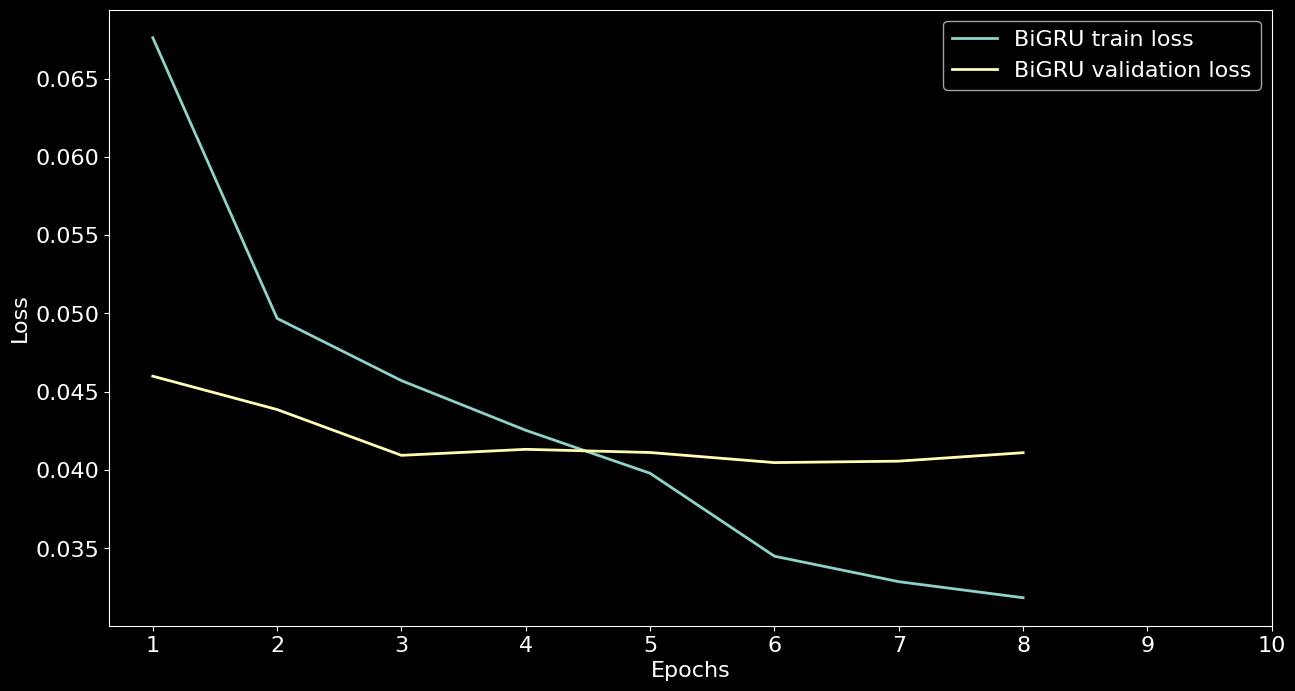

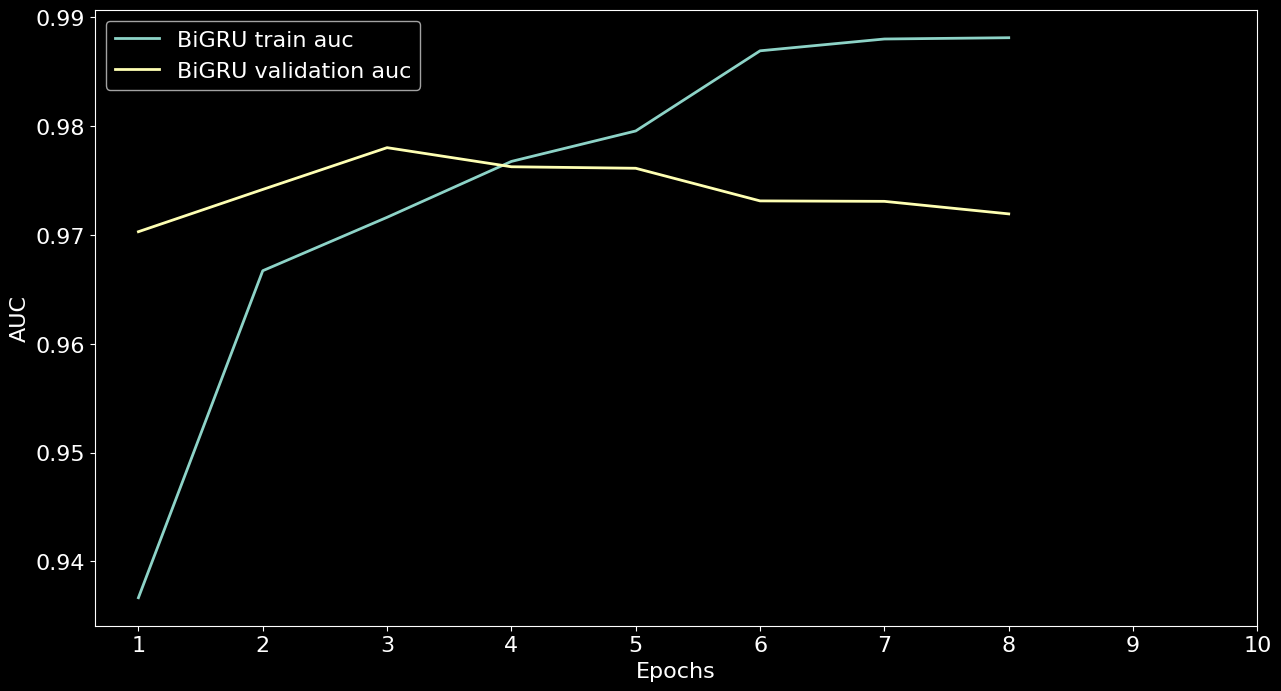

In [16]:
plot_history({'BiGRU': hs}, 10, 'loss')
plot_history({'BiGRU': hs}, 10, 'auc')


###GRU with Attention Model

In [17]:
class AttentionGRUModel(Model):
    def __init__(self, embeddings, bidirectional, recurrent_units, attention_mlp_layers, mlp_layers, mlp_dropout):
        super().__init__()
        self.embeddings = Embedding(
            input_dim=embeddings.shape[0],
            output_dim=embeddings.shape[1],
            weights=[embeddings],
            trainable=False,
            mask_zero=True,
            name='Word_Embeddings'
        )

        self.projection_layer = Dense(units=embeddings.shape[1], activation='tanh', name='Projection')

        self.recurrent_layers = []
        for i, units in enumerate(recurrent_units):
            if bidirectional:
                self.recurrent_layers.append(Bidirectional(GRU(units=units, return_sequences=True, name=f'GRU-{i}'), name=f'BiGRU-{i}'))
            else:
                self.recurrent_layers.append(GRU(units=units, return_sequences=True, name=f'GRU-{i}'))

        self.attention_mlp_layers = []
        for i, units in enumerate(attention_mlp_layers):
            self.attention_mlp_layers.append(TimeDistributed(Dense(units=units, activation='relu'), name=f'ATT-MLP-{i}'))

        self.mlp_layers = []
        for i, units in enumerate(mlp_layers):
            if i == len(mlp_layers) - 1:
                activation = 'sigmoid'
            else:
                activation = 'relu'
            self.mlp_layers.append(Dense(units=units, activation=activation, name=f'MLP-{i}-{activation}'))

        if mlp_dropout is not None:
            self.mlp_dropout = Dropout(rate=mlp_dropout)
        else:
            self.mlp_dropout = None


    def call(self, inputs, **kwargs):
        x = self.embeddings(inputs)

        x = self.projection_layer(x)

        for recurrent_layer in self.recurrent_layers:
            x = recurrent_layer(x)

        for i, attention_mlp_layer in enumerate(self.attention_mlp_layers):
            if i == 0:
                a = attention_mlp_layer(x)
            else:
                a = attention_mlp_layer(a)

        a = tf.nn.softmax(a, axis=-1)
        x = tf.multiply(a, x)
        x = tf.reduce_sum(x, axis=1)

        for i, mlp_layer in enumerate(self.mlp_layers):
            x = mlp_layer(x)
            if self.mlp_dropout != None and i != len(self.mlp_layers) - 1:
                x = self.mlp_dropout(x)

        return x

    def print_summary(self, line_length=None, positions=None, print_fn=None):
        # Fake forward pass to build graph
        comments = np.zeros((1, 100), dtype=np.int32)
        self.predict(comments)
        self.summary(line_length=line_length, positions=positions, print_fn=print_fn)


###GRU with attention classifier

In [18]:
class AttentionGRUToxicityClassifier(ToxicityClassifier):
    def __init__(self):
        super(AttentionGRUToxicityClassifier, self).__init__()

    def build_model(self, train_parameters=None):
        with open(file=f'{train_parameters["preprocessing"]["embeddings"]}.npy', mode='rb') as fin:
            embeddings = np.load(file=fin)
        return AttentionGRUModel(
            embeddings=embeddings,
            bidirectional=train_parameters['bidirectional'],
            recurrent_units=train_parameters['recurrent_units'],
            attention_mlp_layers=train_parameters['attention_mlp_layers'],
            mlp_layers=train_parameters['mlp_layers'],
            mlp_dropout=train_parameters['mlp_dropout']
        )

###BiGRU with attention

In [19]:
configuration = {
    'data':{
        'train_path': '/content/drive/My Drive/data/train.pp.train.split.json',
        'development_path': '/content/drive/My Drive/data/train.pp.dev.split.json',
        'test_path': '/content/drive/My Drive/data/test.pp.json'
    },
    'execution_optimization':{
        'workers': 10,
        'max_queue_size': 30
    },
    'fixed_parameters': {
        'preprocessing': {
            'max_length': 100,
            'embeddings': '/content/drive/My Drive/data/glove.6B.300d',
            'bert': None
        },
        'cooldown_period': 2,
        'patience_early_stopping': 5,
        'patience_reduce_lr': 2,
        'epochs': 10,
        'batch_size': 256

    },
    'hyper_parameters': {
        'bidirectional': True,
        'recurrent_units': [100, 100],
        'attention_mlp_layers': [100, 100, 1],
        'mlp_layers': [100, 100, 6],
        'mlp_dropout': 0.2,
        'learning_rate': 1e-3
    }
}

classifier = AttentionGRUToxicityClassifier()
hs = classifier.train(configuration=configuration)

Creating train generator...
Creating development generator...
Building model...
1/1 [==============================] - 5s 5s/step
Model: "attention_gru_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Word_Embeddings (Embedding  multiple                  32872800  
 )                                                               
                                                                 
 Projection (Dense)          multiple                  90300     
                                                                 
 BiGRU-0 (Bidirectional)     multiple                  241200    
                                                                 
 BiGRU-1 (Bidirectional)     multiple                  181200    
                                                                 
 ATT-MLP-0 (TimeDistributed  multiple                  20100     
 )                                               

---------------------------
Evaluating Development Data
63/63 [==============================] - 3s 8ms/step
---
RoC AUC Scores
|__ Toxic        : 97.87%
|__ Severe toxic : 99.20%
|__ Obscene      : 98.86%
|__ Threat       : 98.07%
|__ Insult       : 98.38%
|__ Identity Hate: 97.97%
|__ Average      : 98.39%

----------------------------
Evaluating Test Data
250/250 [==============================] - 2s 9ms/step
---
RoC AUC Scores
|__ Toxic        : 96.25%
|__ Severe toxic : 98.49%
|__ Obscene      : 97.21%
|__ Threat       : 97.30%
|__ Insult       : 96.66%
|__ Identity Hate: 96.89%
|__ Average      : 97.13%



##Plotting results

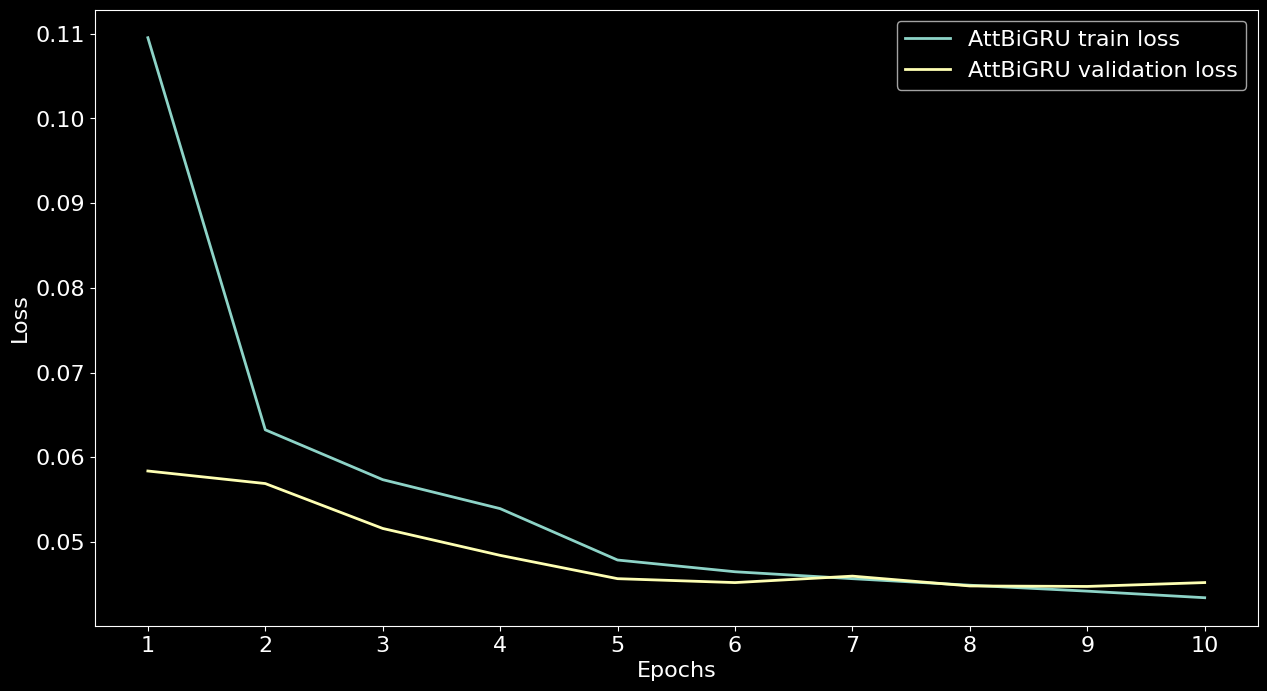

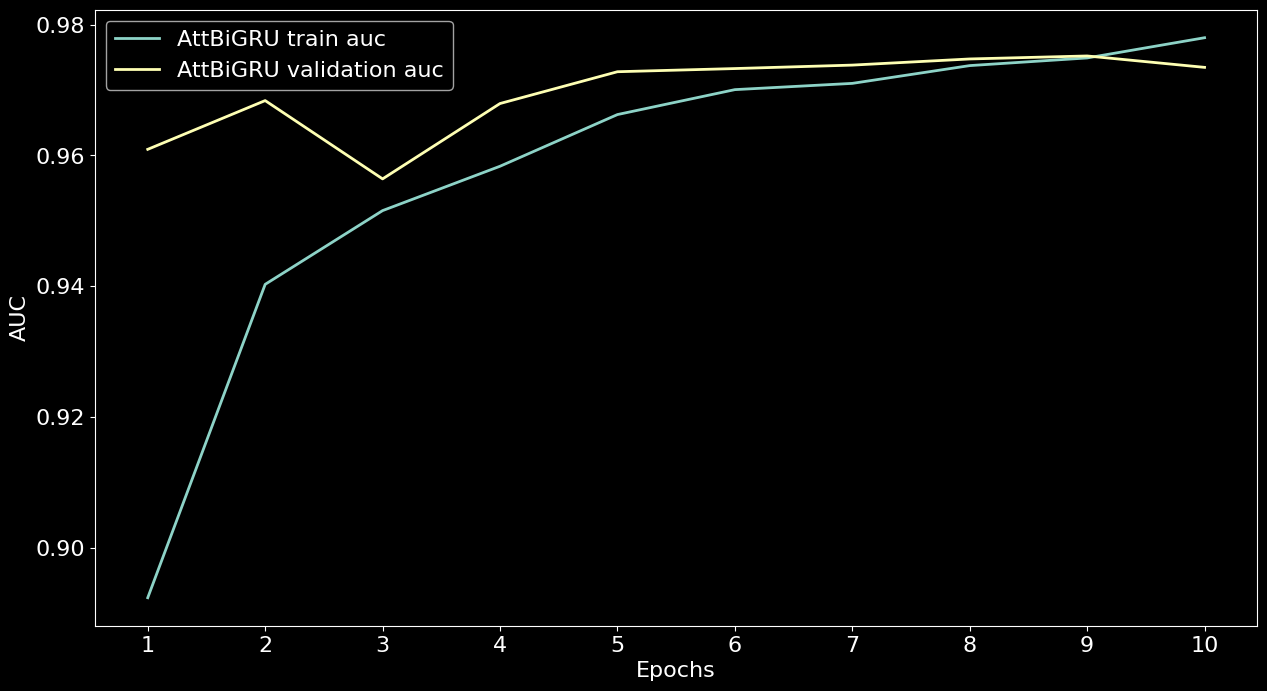

In [20]:
plot_history({'AttBiGRU': hs}, len(hs.history['loss']), 'loss')
plot_history({'AttBiGRU': hs}, len(hs.history['auc']), 'auc')

###GRU model with multiple attentions from single MLP

In [21]:
class MultiAttentionGRUModel(Model):
    def __init__(self, embeddings, bidirectional, recurrent_units, attention_mlp_layers, mlp_layers, mlp_dropout):
        super().__init__()
        self.embeddings = Embedding(
            input_dim=embeddings.shape[0],
            output_dim=embeddings.shape[1],
            weights=[embeddings],
            trainable=False,
            mask_zero=True,
            name='Word_Embeddings'
        )

        self.projection_layer = Dense(units=embeddings.shape[1], activation='tanh', name='Projection')

        self.recurrent_layers = []
        for i, units in enumerate(recurrent_units):
            if bidirectional:
                self.recurrent_layers.append(Bidirectional(GRU(units=units, return_sequences=True), name=f'BiGRU-{i}'))
            else:
                self.recurrent_layers.append(GRU(units=units, return_sequences=True, name=f'GRU-{i}'))

        self.attention_mlp_layers = []
        for i, units in enumerate(attention_mlp_layers):
            self.attention_mlp_layers.append(TimeDistributed(Dense(units=units, activation='relu'), name=f'ATT-MLP-{i}'))

        self.output_mlps = []
        for i in range(6):
            mlp = []
            for j, units in enumerate(mlp_layers):
                if j == len(mlp_layers) - 1:
                    activation = 'sigmoid'
                else:
                    activation = 'relu'
                mlp.append(Dense(units=units, activation=activation, name=f'MLP-{i}-{j}-{activation}'))
            self.output_mlps.append(mlp)

        if mlp_dropout is not None:
            self.mlp_dropout = Dropout(rate=mlp_dropout)
        else:
            self.mlp_dropout = None


    def call(self, inputs, **kwargs):
        x = self.embeddings(inputs)

        x = self.projection_layer(x)

        for recurrent_layer in self.recurrent_layers:
            x = recurrent_layer(x)

        for i, attention_mlp_layer in enumerate(self.attention_mlp_layers):
            if i == 0:
                a = attention_mlp_layer(x)
            else:
                a = attention_mlp_layer(a)

        attended_representations = []
        attention_logits = tf.split(a, num_or_size_splits=6, axis=-1)
        for attention_logit in attention_logits:
            a = tf.nn.softmax(attention_logit, axis=-1)
            attended_representation = tf.multiply(a, x)
            attended_representation = tf.reduce_sum(attended_representation, axis=1)
            attended_representations.append(attended_representation)

        outputs = []
        for attended_representation, output_mlp in zip(attended_representations, self.output_mlps):
            x = attended_representation
            for i, mlp_layer in enumerate(output_mlp):
                x = mlp_layer(x)
                if self.mlp_dropout != None and i != len(output_mlp) - 1:
                    x = self.mlp_dropout(x)
            outputs.append(x)

        output = tf.concat(outputs, axis=-1)
        return output

    def print_summary(self, line_length=None, positions=None, print_fn=None):
        # Fake forward pass to build graph
        comments = np.zeros((1, 100), dtype=np.int32)
        self.predict(comments)
        self.summary(line_length=line_length, positions=positions, print_fn=print_fn)


### GRU classifier with multiple attentions from a single MLP

In [22]:
class MultiAttentionGRUToxicityClassifier(ToxicityClassifier):
    def __init__(self):
        super(MultiAttentionGRUToxicityClassifier, self).__init__()

    def build_model(self, train_parameters=None):
        with open(file=f'{train_parameters["preprocessing"]["embeddings"]}.npy', mode='rb') as fin:
            embeddings = np.load(file=fin)
        return MultiAttentionGRUModel(
            embeddings=embeddings,
            bidirectional=train_parameters['bidirectional'],
            recurrent_units=train_parameters['recurrent_units'],
            attention_mlp_layers=train_parameters['attention_mlp_layers'],
            mlp_layers=train_parameters['mlp_layers'],
            mlp_dropout=train_parameters['mlp_dropout']
        )

###BiGRU with multiple attentions from a single MLP

In [23]:
configuration = {
    'data':{
        'train_path': '/content/drive/My Drive/data/train.pp.train.split.json',
        'development_path': '/content/drive/My Drive/data/train.pp.dev.split.json',
        'test_path': '/content/drive/My Drive/data/test.pp.json'
    },
    'execution_optimization':{
        'workers': 20,
        'max_queue_size': 60
    },
    'fixed_parameters': {
        'preprocessing': {
            'max_length': 100,
            'embeddings': '/content/drive/My Drive/data/glove.6B.300d',
            'bert': None
        },
        'cooldown_period': 2,
        'patience_early_stopping': 5,
        'patience_reduce_lr': 2,
        'epochs': 10,
        'batch_size': 256

    },
    'hyper_parameters': {
        'bidirectional': True,
        'recurrent_units': [100, 100],
        'attention_mlp_layers': [100, 100, 6],
        'mlp_layers': [100, 100, 1],
        'mlp_dropout': 0.2,
        'learning_rate': 1e-3
    }
}

classifier = MultiAttentionGRUToxicityClassifier()
hs = classifier.train(configuration=configuration)

Creating train generator...
Creating development generator...
Building model...
1/1 [==============================] - 5s 5s/step
Model: "multi_attention_gru_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Word_Embeddings (Embedding  multiple                  32872800  
 )                                                               
                                                                 
 Projection (Dense)          multiple                  90300     
                                                                 
 BiGRU-0 (Bidirectional)     multiple                  241200    
                                                                 
 BiGRU-1 (Bidirectional)     multiple                  181200    
                                                                 
 ATT-MLP-0 (TimeDistributed  multiple                  20100     
 )                                         

---------------------------
Evaluating Development Data
63/63 [==============================] - 4s 9ms/step
---
RoC AUC Scores
|__ Toxic        : 97.82%
|__ Severe toxic : 99.20%
|__ Obscene      : 98.92%
|__ Threat       : 99.38%
|__ Insult       : 98.37%
|__ Identity Hate: 98.68%
|__ Average      : 98.73%

----------------------------
Evaluating Test Data
250/250 [==============================] - 2s 9ms/step
---
RoC AUC Scores
|__ Toxic        : 96.31%
|__ Severe toxic : 98.06%
|__ Obscene      : 97.05%
|__ Threat       : 98.23%
|__ Insult       : 96.84%
|__ Identity Hate: 97.92%
|__ Average      : 97.40%



###Plotting results

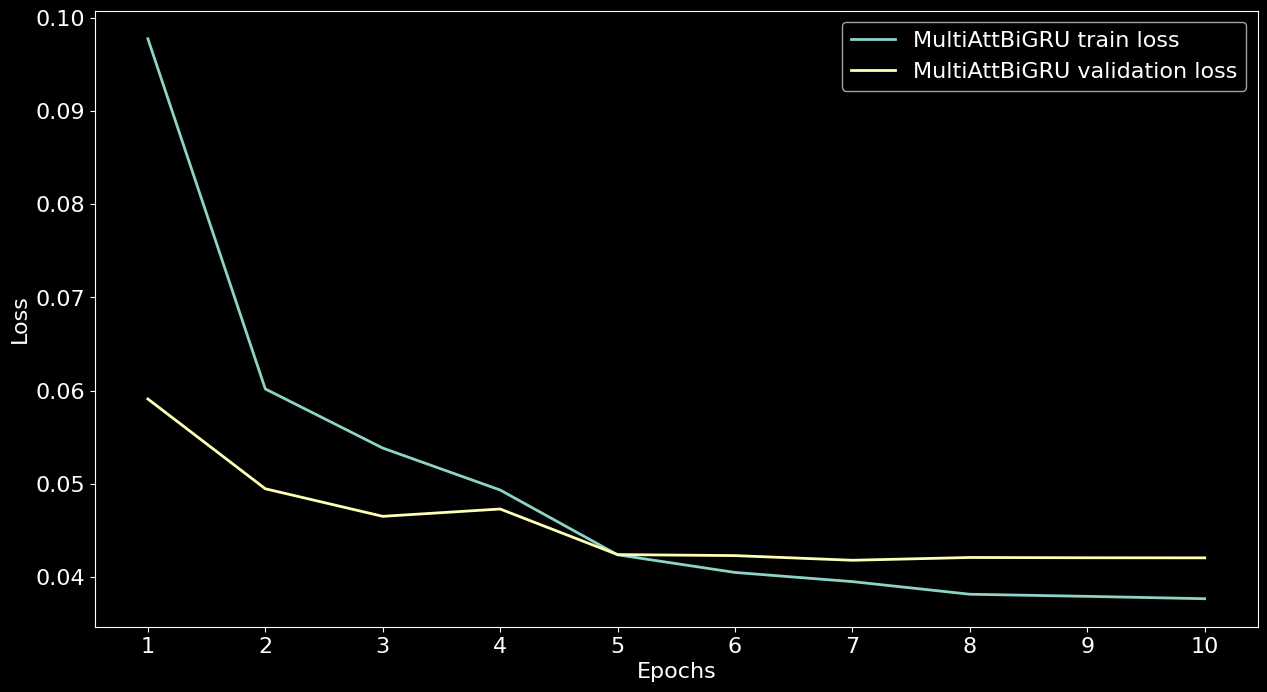

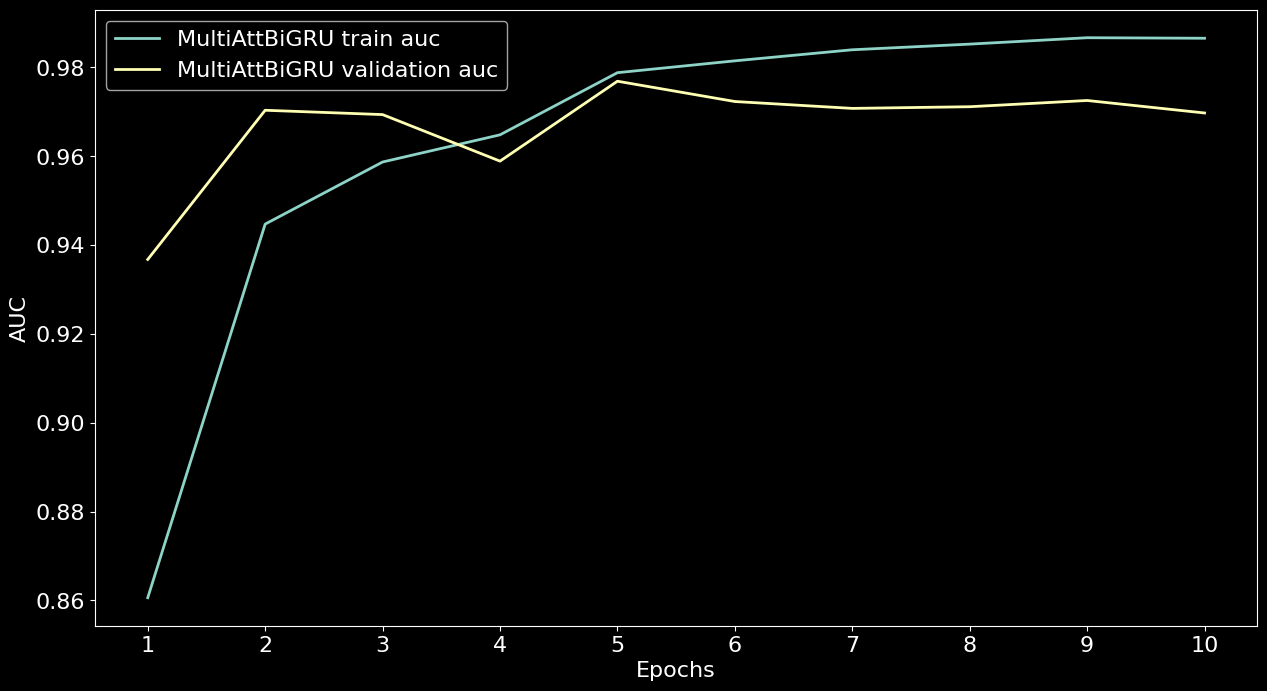

In [24]:
plot_history({'MultiAttBiGRU': hs}, 10, 'loss')
plot_history({'MultiAttBiGRU': hs}, 10, 'auc')

### GRU model with multiple attentions from multiple MLPs

In [25]:
class MultiMLPAttentionGRUModel(Model):
    def __init__(self, embeddings, bidirectional, recurrent_units, attention_mlp_layers, mlp_layers, mlp_dropout):
        super().__init__()
        self.embeddings = Embedding(
            input_dim=embeddings.shape[0],
            output_dim=embeddings.shape[1],
            weights=[embeddings],
            trainable=False,
            mask_zero=True,
            name='Word_Embeddings'
        )

        self.projection_layer = Dense(units=embeddings.shape[1], activation='tanh', name='Projection')

        self.recurrent_layers = []
        for i, units in enumerate(recurrent_units):
            if bidirectional:
                self.recurrent_layers.append(Bidirectional(GRU(units=units, return_sequences=True), name=f'BiGRU-{i}'))
            else:
                self.recurrent_layers.append(GRU(units=units, return_sequences=True, name=f'GRU-{i}'))

        self.attention_mlps = []
        for i in range(6):
            attention_mlp = []
            for j, units in enumerate(attention_mlp_layers):
                attention_mlp.append(TimeDistributed(Dense(units=units, activation='relu'), name=f'ATT-MLP-{i}-{j}'))
            self.attention_mlps.append(attention_mlp)

        self.output_mlps = []
        for i in range(6):
            mlp = []
            for j, units in enumerate(mlp_layers):
                if j == len(mlp_layers) - 1:
                    activation = 'sigmoid'
                else:
                    activation = 'relu'
                mlp.append(Dense(units=units, activation=activation, name=f'MLP-{i}-{j}-{activation}'))
            self.output_mlps.append(mlp)

        if mlp_dropout is not None:
            self.mlp_dropout = Dropout(rate=mlp_dropout)
        else:
            self.mlp_dropout = None


    def call(self, inputs, **kwargs):
        x = self.embeddings(inputs)

        x = self.projection_layer(x)

        for recurrent_layer in self.recurrent_layers:
            x = recurrent_layer(x)

        attention_logits = []
        for attention_mlp in self.attention_mlps:
            for i, attention_mlp_layer in enumerate(attention_mlp):
                if i == 0:
                    attention_logit = attention_mlp_layer(x)
                else:
                    attention_logit = attention_mlp_layer(attention_logit)
            attention_logits.append(attention_logit)

        attended_representations = []
        for attention_logit in attention_logits:
            a = tf.nn.softmax(attention_logit, axis=-1)
            attended_representation = tf.multiply(a, x)
            attended_representation = tf.reduce_sum(attended_representation, axis=1)
            attended_representations.append(attended_representation)

        outputs = []
        for attended_representation, output_mlp in zip(attended_representations, self.output_mlps):
            x = attended_representation
            for i, mlp_layer in enumerate(output_mlp):
                x = mlp_layer(x)
                if self.mlp_dropout != None and i != len(output_mlp) - 1:
                    x = self.mlp_dropout(x)
            outputs.append(x)

        output = tf.concat(outputs, axis=-1)
        return output

    def print_summary(self, line_length=None, positions=None, print_fn=None):
        # Fake forward pass to build graph
        comments = np.zeros((1, 100), dtype=np.int32)
        self.predict(comments)
        self.summary(line_length=line_length, positions=positions, print_fn=print_fn)


###GRU classifier with multiple attentions from multiple MLPs

In [26]:
class MultiMLPAttentionGRUToxicityClassifier(ToxicityClassifier):
    def __init__(self):
        super(MultiMLPAttentionGRUToxicityClassifier, self).__init__()

    def build_model(self, train_parameters=None):
        with open(file=f'{train_parameters["preprocessing"]["embeddings"]}.npy', mode='rb') as fin:
            embeddings = np.load(file=fin)
        return MultiMLPAttentionGRUModel(
            embeddings=embeddings,
            bidirectional=train_parameters['bidirectional'],
            recurrent_units=train_parameters['recurrent_units'],
            attention_mlp_layers=train_parameters['attention_mlp_layers'],
            mlp_layers=train_parameters['mlp_layers'],
            mlp_dropout=train_parameters['mlp_dropout']
        )

###BiGRU with multiple attentions from multiple MLPs

In [27]:
configuration = {
    'data':{
        'train_path': '/content/drive/My Drive/data/train.pp.train.split.json',
        'development_path': '/content/drive/My Drive/data/train.pp.dev.split.json',
        'test_path': '/content/drive/My Drive/data/test.pp.json'
    },
    'execution_optimization':{
        'workers': 20,
        'max_queue_size': 60
    },
    'fixed_parameters': {
        'preprocessing': {
            'max_length': 100,
            'embeddings': '/content/drive/My Drive/data/glove.6B.300d',
            'bert': None
        },
        'cooldown_period': 2,
        'patience_early_stopping': 5,
        'patience_reduce_lr': 2,
        'epochs': 10,
        'batch_size': 256

    },
    'hyper_parameters': {
        'bidirectional': True,
        'recurrent_units': [100, 100],
        'attention_mlp_layers': [100, 100, 1],
        'mlp_layers': [100, 100, 1],
        'mlp_dropout': 0.2,
        'learning_rate': 1e-3
    }
}

classifier = MultiMLPAttentionGRUToxicityClassifier()
hs = classifier.train(configuration=configuration)

Creating train generator...
Creating development generator...
Building model...
1/1 [==============================] - 5s 5s/step
Model: "multi_mlp_attention_gru_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Word_Embeddings (Embedding  multiple                  32872800  
 )                                                               
                                                                 
 Projection (Dense)          multiple                  90300     
                                                                 
 BiGRU-0 (Bidirectional)     multiple                  241200    
                                                                 
 BiGRU-1 (Bidirectional)     multiple                  181200    
                                                                 
 ATT-MLP-0-0 (TimeDistribut  multiple                  20100     
 ed)                                   

---------------------------
Evaluating Development Data
63/63 [==============================] - 4s 10ms/step
---
RoC AUC Scores
|__ Toxic        : 97.58%
|__ Severe toxic : 99.23%
|__ Obscene      : 98.82%
|__ Threat       : 99.32%
|__ Insult       : 98.66%
|__ Identity Hate: 98.59%
|__ Average      : 98.70%

----------------------------
Evaluating Test Data
250/250 [==============================] - 3s 10ms/step
---
RoC AUC Scores
|__ Toxic        : 96.24%
|__ Severe toxic : 98.43%
|__ Obscene      : 96.95%
|__ Threat       : 98.61%
|__ Insult       : 96.75%
|__ Identity Hate: 98.15%
|__ Average      : 97.52%



###Plotting results

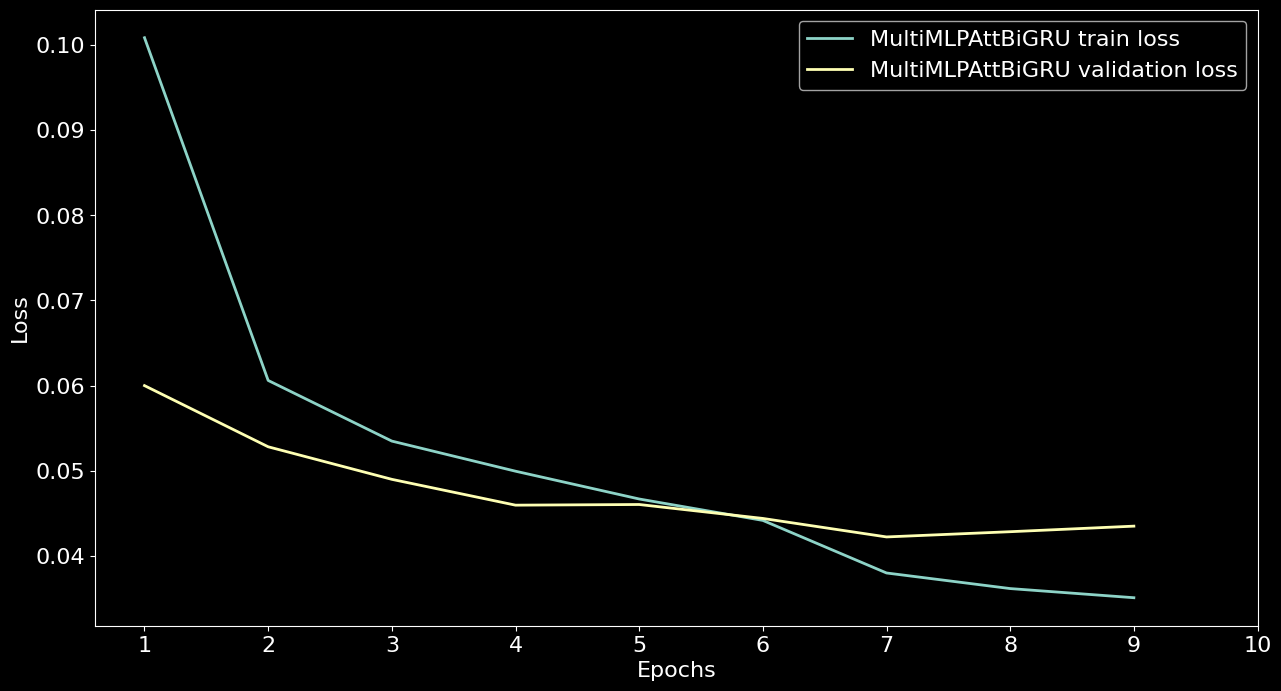

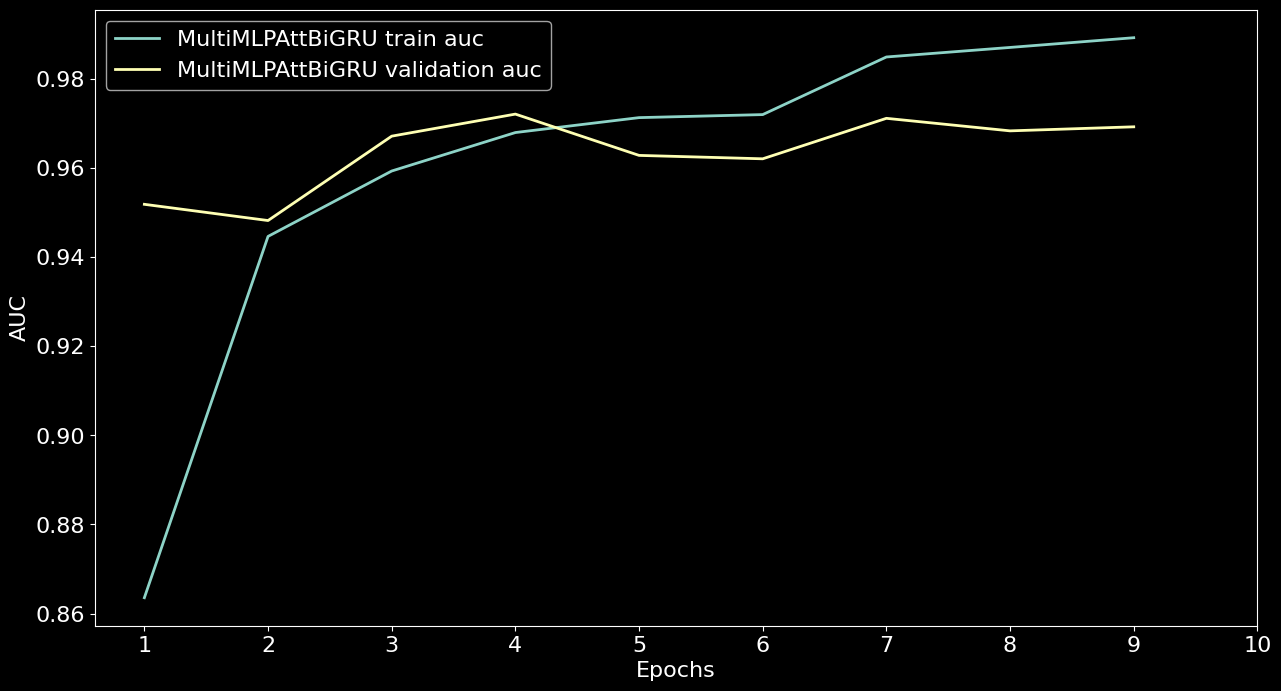

In [28]:
plot_history({'MultiMLPAttBiGRU': hs}, 10, 'loss')
plot_history({'MultiMLPAttBiGRU': hs}, 10, 'auc')

###BERT model

In [29]:
class BERTModel(Model):
    def __init__(self, version, dropout_rate, hidden_representation):
        super().__init__()
        bert_config = AutoConfig.from_pretrained(pretrained_model_name_or_path=version)
        bert_config.hidden_dropout_prob = dropout_rate
        self.bert_encoder = TFAutoModel.from_pretrained(
            pretrained_model_name_or_path=version,
            config=bert_config,
            from_pt=True # Explicitly load from PyTorch checkpoint
        )
        self.hidden_representation = hidden_representation
        self.output_layer = Dense(units=6, activation='sigmoid', kernel_initializer=TruncatedNormal(stddev=0.2), name='Output')
        self.dropout = Dropout(rate=dropout_rate)


    def call(self, inputs, **kwargs):
        x = self.bert_encoder(inputs, **kwargs)

        if self.hidden_representation == 'pooler':
            pooled_output = x[1]
        else:
            pooled_output = x[0][:, 0]
        pooled_output = self.dropout(pooled_output)

        output = self.output_layer(pooled_output)

        return output

    def print_summary(self, line_length=None, positions=None, print_fn=None):
        # Fake forward pass to build graph
        comments = np.zeros((1, 100), dtype=np.int32)
        self.predict(comments)
        self.summary(line_length=line_length, positions=positions, print_fn=print_fn)

###BERT classifier

In [30]:
class BERTClassifier(ToxicityClassifier):
    def __init__(self):
        super(BERTClassifier, self).__init__()

    def build_model(self, train_parameters=None):
        return BERTModel(
            version=train_parameters['bert'],
            dropout_rate=train_parameters['dropout_rate'],
            hidden_representation=train_parameters['hidden_representation']
        )

###BERT

In [31]:
configuration = {
    'data':{
        'train_path': '/content/drive/My Drive/data/train.pp.train.split.json',
        'development_path': '/content/drive/My Drive/data/train.pp.dev.split.json',
        'test_path': '/content/drive/My Drive/data/test.pp.json'
    },
    'execution_optimization':{
        'workers': 20,
        'max_queue_size': 60
    },
    'fixed_parameters': {
        'preprocessing': {
            'max_length': 100,
            'embeddings': None,
            'bert': 'bert-base-uncased'
        },
        'cooldown_period': 1,
        'patience_early_stopping': 2,
        'patience_reduce_lr': 1,
        'epochs': 5,
        'batch_size': 128,
        'bert': 'bert-base-uncased'
    },
    'hyper_parameters': {
        'hidden_representation': 'cls',
        'dropout_rate': 0.2,
        'learning_rate': 2e-5
    }
}

classifier = BERTClassifier()
hs = classifier.train(configuration=configuration)

Creating train generator...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Creating development generator...
Building model...


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Al

1/1 [==============================] - 5s 5s/step
Model: "bert_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_bert_model (TFBertModel  multiple                  109482240 
 )                                                               
                                                                 
 Output (Dense)              multiple                  4614      
                                                                 
 dropout_41 (Dropout)        multiple                  0         
                                                                 
Total params: 109486854 (417.66 MB)
Trainable params: 109486854 (417.66 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/5


1122/1122 [==============================] - 253s 190ms/step - loss: 0.0590 - auc: 0.9478 - val_loss: 0.0392 - val_auc: 0.9898 - lr: 2.0000e-05
Epoch 2/5
1122/1122 [==============================] - ETA: 0s - loss: 0.0401 - auc: 0.9818
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999949504854e-06.
1122/1122 [==============================] - 185s 164ms/step - loss: 0.0401 - auc: 0.9818 - val_loss: 0.0365 - val_auc: 0.9896 - lr: 2.0000e-05
Epoch 3/5
1122/1122 [==============================] - ETA: 0s - loss: 0.0342 - auc: 0.9868
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.0000000233721948e-07.
1122/1122 [==============================] - 170s 151ms/step - loss: 0.0342 - auc: 0.9868 - val_loss: 0.0359 - val_auc: 0.9896 - lr: 2.0000e-06

Epoch 3: early stopping
---------------------------
Evaluating Development Data
125/125 [==============================] - 9s 54ms/step
---
RoC AUC Scores
|__ Toxic        : 98.72%
|__ Severe toxic : 99.39%
|__ Obscene      : 99.

###Plotting results

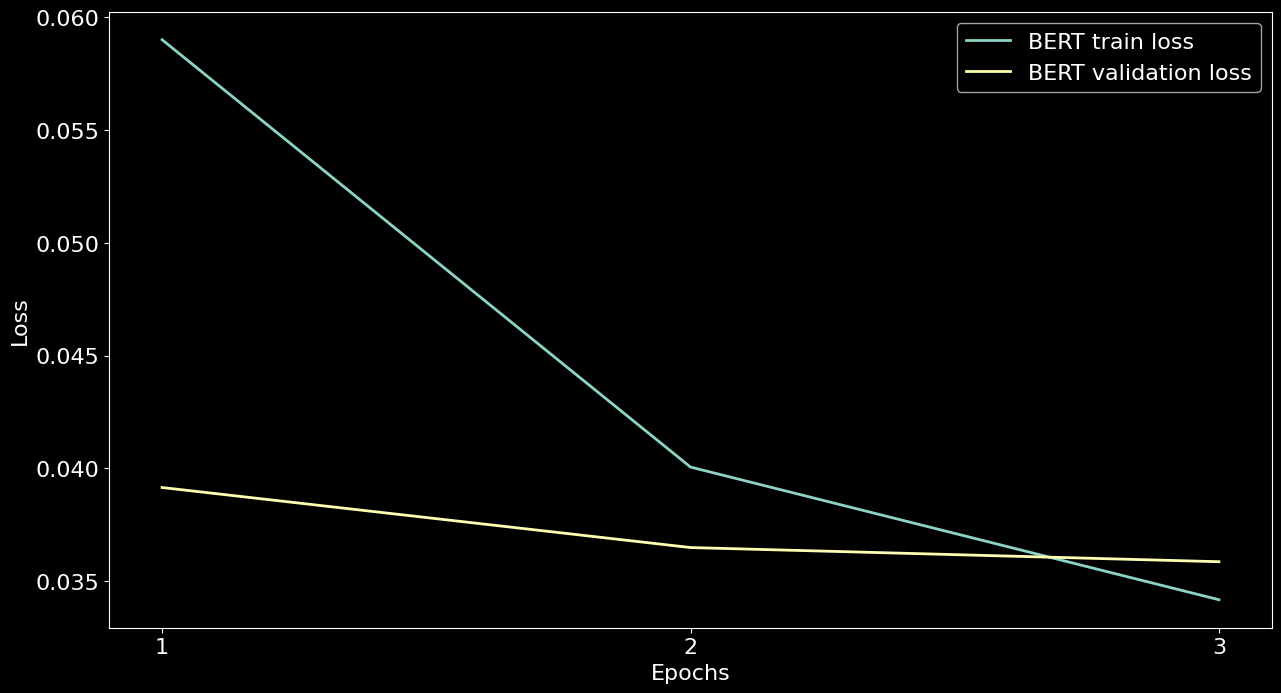

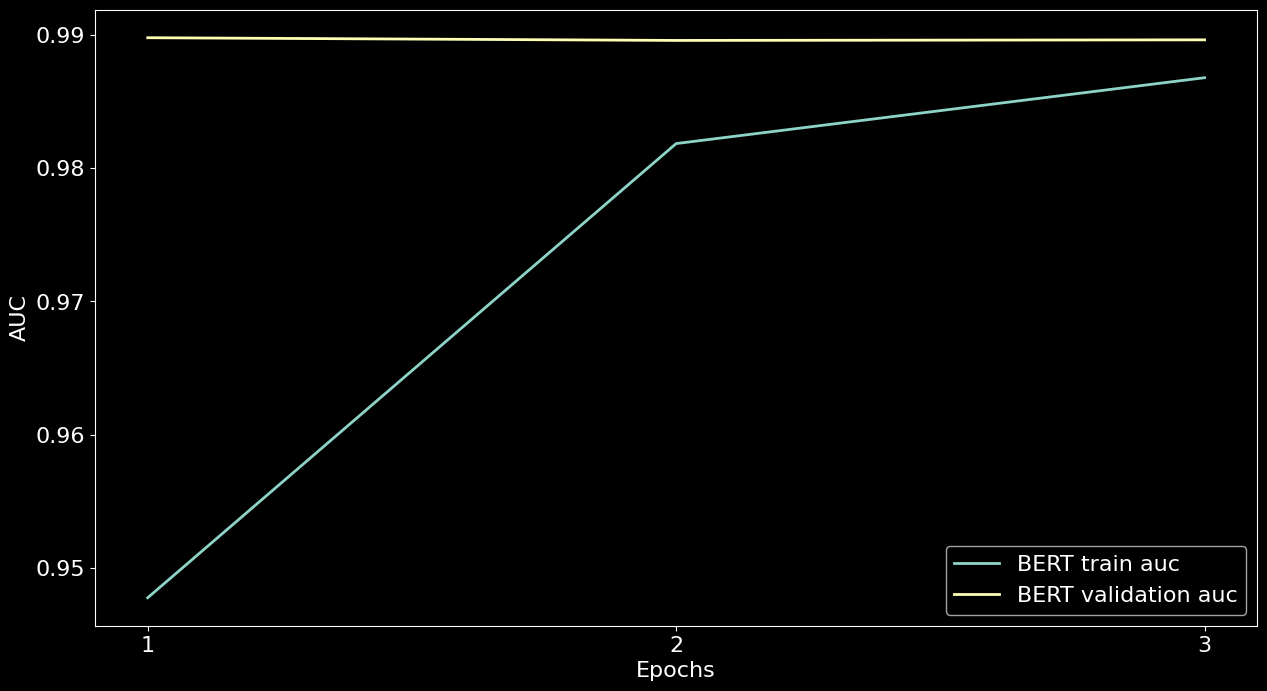

In [32]:
plot_history({'BERT': hs}, len(hs.history['loss']), 'loss')
plot_history({'BERT': hs}, len(hs.history['loss']), 'auc')